In [1]:
# ============================================================
#  JV Program – VLR México
#  Script 04: Figuras Capítulo 8 — Prototipo (Entregable 4)
#  Genera: Figura 28 (Arquitectura), Figura 29 (Dashboard mockup),
#          Figura 30 (Modelo de datos en estrella)
#  Ejecutar DESPUÉS de los Scripts 01, 02 y 03
# ============================================================

In [2]:
# ── CELDA 1: Importaciones ────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import numpy as np
import os
import warnings
warnings.filterwarnings("ignore")
 
plt.rcParams.update({
    "font.family": "Arial",
    "figure.dpi":  150,
})
 
COLOR_CORP  = "#2E75B6"
COLOR_DARK  = "#1a3a5c"
COLOR_TEAL  = "#1D9E75"
COLOR_AMBER = "#EF9F27"
COLOR_RED   = "#E05C2E"
COLOR_GRAY  = "#888780"
COLOR_PURPLE= "#5B4DA5"
 
os.makedirs("figuras_cap8", exist_ok=True)
 
def save(name):
    path = f"figuras_cap8/{name}"
    plt.savefig(path, dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()
    size = os.path.getsize(path) / 1024
    print(f"✅ {name}  ({size:.1f} KB)")
 
def caja(ax, x, y, w, h, texto, color, tcolor="white", fs=9, alpha=1.0):
    box = FancyBboxPatch((x, y), w, h,
                          boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor="white",
                          linewidth=1.5, alpha=alpha, zorder=3)
    ax.add_patch(box)
    lines = texto.split("\n")
    dy = h / (len(lines) + 1)
    for i, line in enumerate(lines):
        ax.text(x + w/2, y + h - dy*(i+1), line,
                ha="center", va="center",
                fontsize=fs, color=tcolor,
                fontweight="bold" if i == 0 else "normal",
                zorder=4)
 
def flecha(ax, x1, y1, x2, y2, color="#2E75B6", lw=1.8):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="-|>", color=color,
                                lw=lw, mutation_scale=15), zorder=2)
 
print("✅ Librerías y funciones auxiliares cargadas")

✅ Librerías y funciones auxiliares cargadas


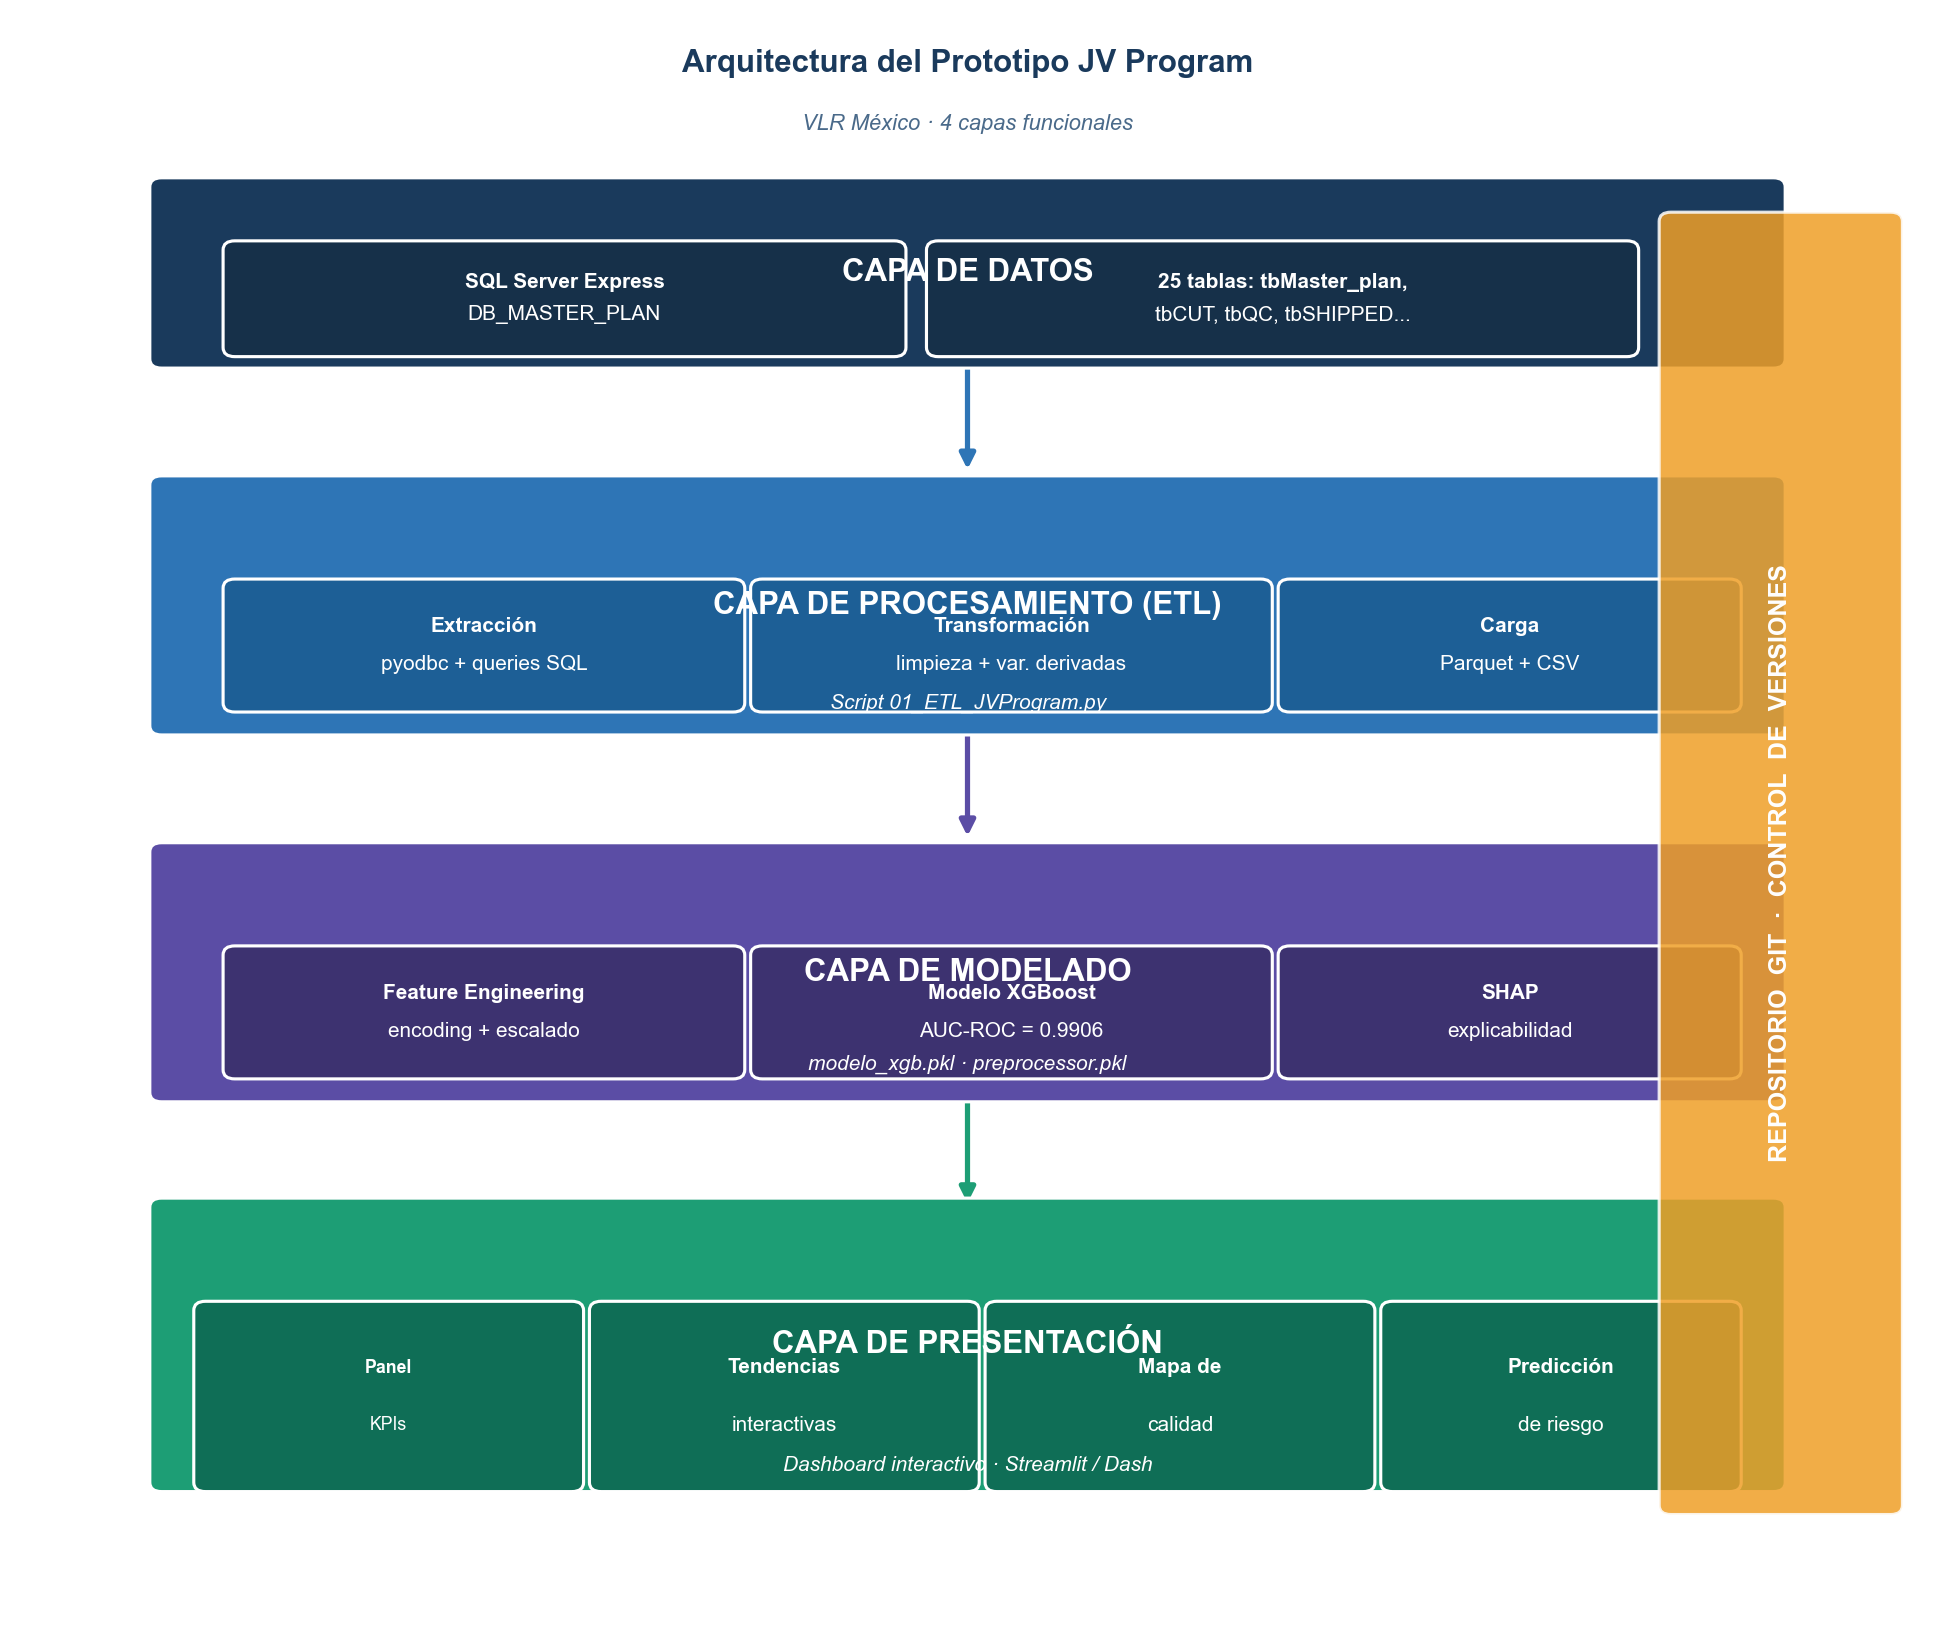

✅ figura28_arquitectura_prototipo.png  (185.3 KB)


In [3]:
 
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 28 — Arquitectura general del prototipo (4 capas)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 2 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 11))
ax.set_xlim(0, 13)
ax.set_ylim(0, 14)
ax.axis("off")
ax.set_facecolor("white")
 
ax.text(6.5, 13.5, "Arquitectura del Prototipo JV Program",
        ha="center", fontsize=15, fontweight="bold", color=COLOR_DARK)
ax.text(6.5, 13.0, "VLR México · 4 capas funcionales",
        ha="center", fontsize=10.5, color="#4a6a8a", style="italic")
 
# ── CAPA 1: Datos ──────────────────────────────────────────────────────────
caja(ax, 1, 11, 11,1.5, "CAPA DE DATOS",
     COLOR_DARK, fs=15)
caja(ax, 1.5, 11.1, 4.5, 0.85,
     "SQL Server Express\nDB_MASTER_PLAN", "#163049", fs=10)
caja(ax, 6.3, 11.1, 4.7, 0.85,
     "25 tablas: tbMaster_plan,\ntbCUT, tbQC, tbSHIPPED...", "#163049", fs=10)
 
flecha(ax, 6.5, 11.0, 6.5, 10.0, color=COLOR_CORP, lw=2.5)
 
# ── CAPA 2: Procesamiento ───────────────────────────────────────────────────
caja(ax, 1, 7.8, 11, 2.1, "CAPA DE PROCESAMIENTO (ETL)",
     COLOR_CORP, fs=15)
caja(ax, 1.5, 8.0, 3.4, 1.0,
     "Extracción\npyodbc + queries SQL", "#1d5f96", fs=10)
caja(ax, 5.1, 8.0, 3.4, 1.0,
     "Transformación\nlimpieza + var. derivadas", "#1d5f96", fs=10)
caja(ax, 8.7, 8.0, 3.0, 1.0,
     "Carga\nParquet + CSV", "#1d5f96", fs=10)
ax.text(6.5, 7.95, "Script 01_ETL_JVProgram.py", ha="center",
        fontsize=10, color="white", style="italic")
 
flecha(ax, 6.5, 7.8, 6.5, 6.8, color=COLOR_PURPLE, lw=2.5)
 
# ── CAPA 3: Modelado ─────────────────────────────────────────────────────────
caja(ax, 1, 4.6, 11, 2.1, "CAPA DE MODELADO",
     COLOR_PURPLE, fs=15)
caja(ax, 1.5, 4.8, 3.4, 1.0,
     "Feature Engineering\nencoding + escalado", "#3d3270", fs=10)
caja(ax, 5.1, 4.8, 3.4, 1.0,
     "Modelo XGBoost\nAUC-ROC = 0.9906", "#3d3270", fs=10)
caja(ax, 8.7, 4.8, 3.0, 1.0,
     "SHAP\nexplicabilidad", "#3d3270", fs=10)
ax.text(6.5, 4.8, "modelo_xgb.pkl · preprocessor.pkl", ha="center",
        fontsize=10, color="white", style="italic")
 
flecha(ax, 6.5, 4.6, 6.5, 3.6, color=COLOR_TEAL, lw=2.5)
 
# ── CAPA 4: Presentación ─────────────────────────────────────────────────────
caja(ax, 1, 1.2, 11, 2.4, "CAPA DE PRESENTACIÓN",
     COLOR_TEAL, fs=15)
caja(ax, 1.3, 1.2, 2.5, 1.5,
     "Panel\nKPIs", "#0f6e56", fs=8.5)
caja(ax, 4.0, 1.2, 2.5, 1.5,
     "Tendencias\ninteractivas", "#0f6e56", fs=10)
caja(ax, 6.7, 1.2, 2.5, 1.5,
     "Mapa de\ncalidad", "#0f6e56", fs=10)
caja(ax, 9.4, 1.2, 2.3, 1.5,
     "Predicción\nde riesgo", "#0f6e56", fs=10)
ax.text(6.5, 1.3, "Dashboard interactivo · Streamlit / Dash", ha="center",
        fontsize=10, color="white", style="italic")
 
# ── Repositorio (capa transversal) ──────────────────────────────────────────
rep = FancyBboxPatch((11.3, 1.0), 1.5, 11.2,
                      boxstyle="round,pad=0.08",
                      facecolor=COLOR_AMBER, edgecolor="white",
                      linewidth=1.5, alpha=0.85, zorder=3)
ax.add_patch(rep)
ax.text(12.05, 6.6, "REPOSITORIO  GIT  ·  CONTROL  DE  VERSIONES",
        ha="center", va="center", fontsize=12, fontweight="bold",
        color="white", rotation=90, zorder=4)
 
plt.tight_layout()
save("figura28_arquitectura_prototipo.png")
 

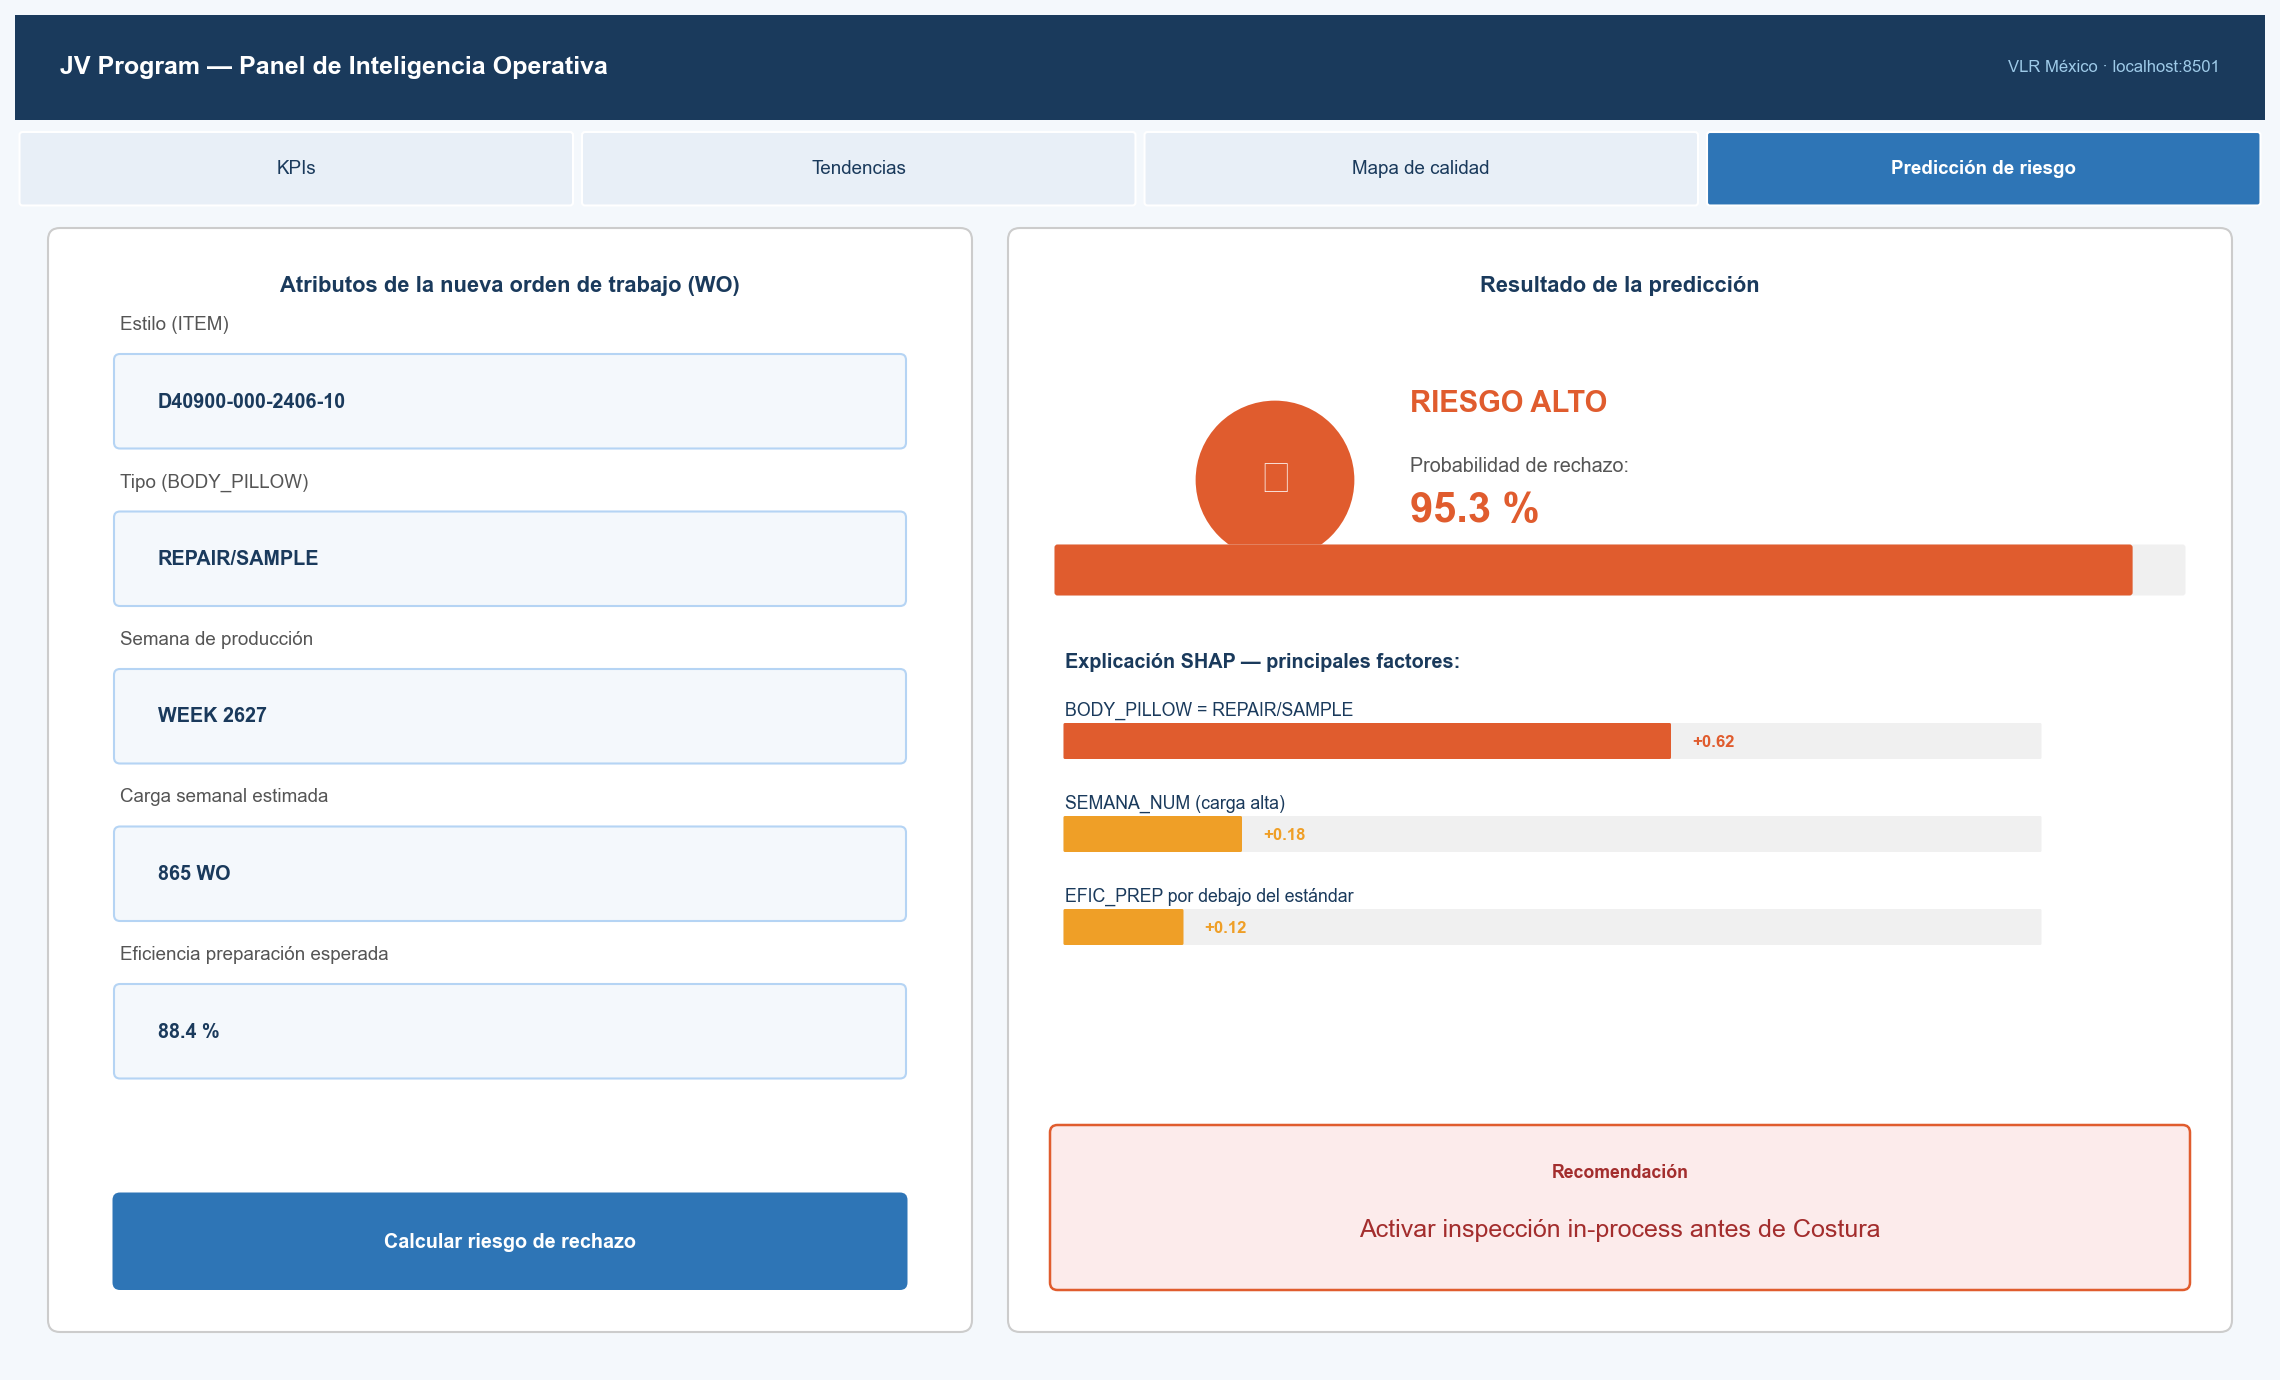

✅ figura29_dashboard_mockup_prediccion.png  (157.6 KB)


In [4]:
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 29 — Mockup estático del dashboard (pestaña Predicción de Riesgo)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 3 ───────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 9))
fig.patch.set_facecolor("#F4F8FC")
ax = fig.add_axes([0, 0, 1, 1])
ax.set_xlim(0, 15)
ax.set_ylim(0, 9)
ax.axis("off")
 
# ── Barra superior ────────────────────────────────────────────────────────────
top_bar = FancyBboxPatch((0, 8.3), 15, 0.7, boxstyle="square,pad=0",
                          facecolor=COLOR_DARK, edgecolor="none", zorder=2)
ax.add_patch(top_bar)
ax.text(0.3, 8.65, "JV Program — Panel de Inteligencia Operativa",
        fontsize=12, color="white", fontweight="bold", va="center")
ax.text(14.7, 8.65, "VLR México · localhost:8501", fontsize=8,
        color="#9ECAE8", va="center", ha="right")
 
# ── Pestañas ───────────────────────────────────────────────────────────────
tabs = ["KPIs", "Tendencias", "Mapa de calidad", "Predicción de riesgo"]
tab_w = 15 / len(tabs)
for i, tab in enumerate(tabs):
    active = (tab == "Predicción de riesgo")
    color = COLOR_CORP if active else "#E8EFF7"
    tcolor = "white" if active else COLOR_DARK
    rect = FancyBboxPatch((i*tab_w + 0.05, 7.75), tab_w - 0.1, 0.45,
                           boxstyle="round,pad=0.02",
                           facecolor=color, edgecolor="white", linewidth=1, zorder=3)
    ax.add_patch(rect)
    ax.text(i*tab_w + tab_w/2, 7.97, tab, ha="center", va="center",
            fontsize=9, color=tcolor, fontweight="bold" if active else "normal", zorder=4)
 
# ── Panel izquierdo: formulario ──────────────────────────────────────────────
form_box = FancyBboxPatch((0.3, 0.3), 6.0, 7.2, boxstyle="round,pad=0.08",
                           facecolor="white", edgecolor="#CCCCCC", linewidth=1, zorder=2)
ax.add_patch(form_box)
ax.text(3.3, 7.15, "Atributos de la nueva orden de trabajo (WO)",
        ha="center", fontsize=10.5, fontweight="bold", color=COLOR_DARK)
 
campos = [
    ("Estilo (ITEM)", "D40900-000-2406-10"),
    ("Tipo (BODY_PILLOW)", "REPAIR/SAMPLE"),
    ("Semana de producción", "WEEK 2627"),
    ("Carga semanal estimada", "865 WO"),
    ("Eficiencia preparación esperada", "88.4 %"),
]
for i, (label, val) in enumerate(campos):
    y = 6.4 - i*1.05
    ax.text(0.7, y + 0.5, label, fontsize=9, color="#555555")
    field = FancyBboxPatch((0.7, y - 0.25), 5.2, 0.55,
                            boxstyle="round,pad=0.04",
                            facecolor="#F4F8FC", edgecolor="#B5D4F4", linewidth=1, zorder=3)
    ax.add_patch(field)
    ax.text(0.95, y + 0.02, val, fontsize=9.5, color=COLOR_DARK,
            fontweight="bold", va="center", zorder=4)
 
btn = FancyBboxPatch((0.7, 0.55), 5.2, 0.55, boxstyle="round,pad=0.05",
                      facecolor=COLOR_CORP, edgecolor="none", zorder=3)
ax.add_patch(btn)
ax.text(3.3, 0.82, "Calcular riesgo de rechazo", ha="center", va="center",
        fontsize=9.5, color="white", fontweight="bold", zorder=4)
 
# ── Panel derecho: resultado ─────────────────────────────────────────────────
res_box = FancyBboxPatch((6.7, 0.3), 8.0, 7.2, boxstyle="round,pad=0.08",
                          facecolor="white", edgecolor="#CCCCCC", linewidth=1, zorder=2)
ax.add_patch(res_box)
ax.text(10.7, 7.15, "Resultado de la predicción", ha="center",
        fontsize=10.5, fontweight="bold", color=COLOR_DARK)
 
# Semáforo
semaforo = Circle((8.4, 5.9), 0.55, facecolor=COLOR_RED, edgecolor="white",
                   linewidth=3, zorder=3)
ax.add_patch(semaforo)
ax.text(8.4, 5.9, "⚠", ha="center", va="center", fontsize=22, color="white", zorder=4)
 
ax.text(9.3, 6.35, "RIESGO ALTO", fontsize=14, fontweight="bold", color=COLOR_RED)
ax.text(9.3, 5.95, "Probabilidad de rechazo:", fontsize=9.5, color="#555555")
ax.text(9.3, 5.62, "95.3 %", fontsize=20, fontweight="bold", color=COLOR_RED)
 
# Barra de probabilidad
prob_bg = FancyBboxPatch((6.95, 5.15), 7.5, 0.3, boxstyle="round,pad=0.02",
                          facecolor="#F0F0F0", edgecolor="none", zorder=3)
ax.add_patch(prob_bg)
prob_fill = FancyBboxPatch((6.95, 5.15), 7.5*0.953, 0.3, boxstyle="round,pad=0.02",
                            facecolor=COLOR_RED, edgecolor="none", zorder=4)
ax.add_patch(prob_fill)
 
ax.text(7.0, 4.65, "Explicación SHAP — principales factores:", fontsize=9.5,
        fontweight="bold", color=COLOR_DARK)
 
shap_factores = [
    ("BODY_PILLOW = REPAIR/SAMPLE", 0.62, COLOR_RED),
    ("SEMANA_NUM (carga alta)", 0.18, COLOR_AMBER),
    ("EFIC_PREP por debajo del estándar", 0.12, COLOR_AMBER),
]
for i, (factor, impacto, color) in enumerate(shap_factores):
    y = 4.15 - i*0.62
    ax.text(7.0, y + 0.18, factor, fontsize=8.5, color=COLOR_DARK)
    bar_bg = FancyBboxPatch((7.0, y - 0.1), 6.5, 0.22, boxstyle="round,pad=0.01",
                             facecolor="#F0F0F0", edgecolor="none", zorder=3)
    ax.add_patch(bar_bg)
    bar_fill = FancyBboxPatch((7.0, y - 0.1), 6.5*impacto, 0.22, boxstyle="round,pad=0.01",
                               facecolor=color, edgecolor="none", zorder=4)
    ax.add_patch(bar_fill)
    ax.text(7.0 + 6.5*impacto + 0.15, y, f"+{impacto:.2f}", fontsize=8,
            color=color, fontweight="bold", va="center")
 
# Recomendación
rec_box = FancyBboxPatch((6.95, 0.55), 7.5, 1.0, boxstyle="round,pad=0.05",
                          facecolor="#FCEBEB", edgecolor=COLOR_RED, linewidth=1.2, zorder=3)
ax.add_patch(rec_box)
ax.text(10.7, 1.25, "Recomendación", ha="center", fontsize=8.5,
        fontweight="bold", color="#A32D2D")
ax.text(10.7, 0.85, "Activar inspección in-process antes de Costura",
        ha="center", fontsize=12, color="#A32D2D")
 
plt.tight_layout()
save("figura29_dashboard_mockup_prediccion.png")

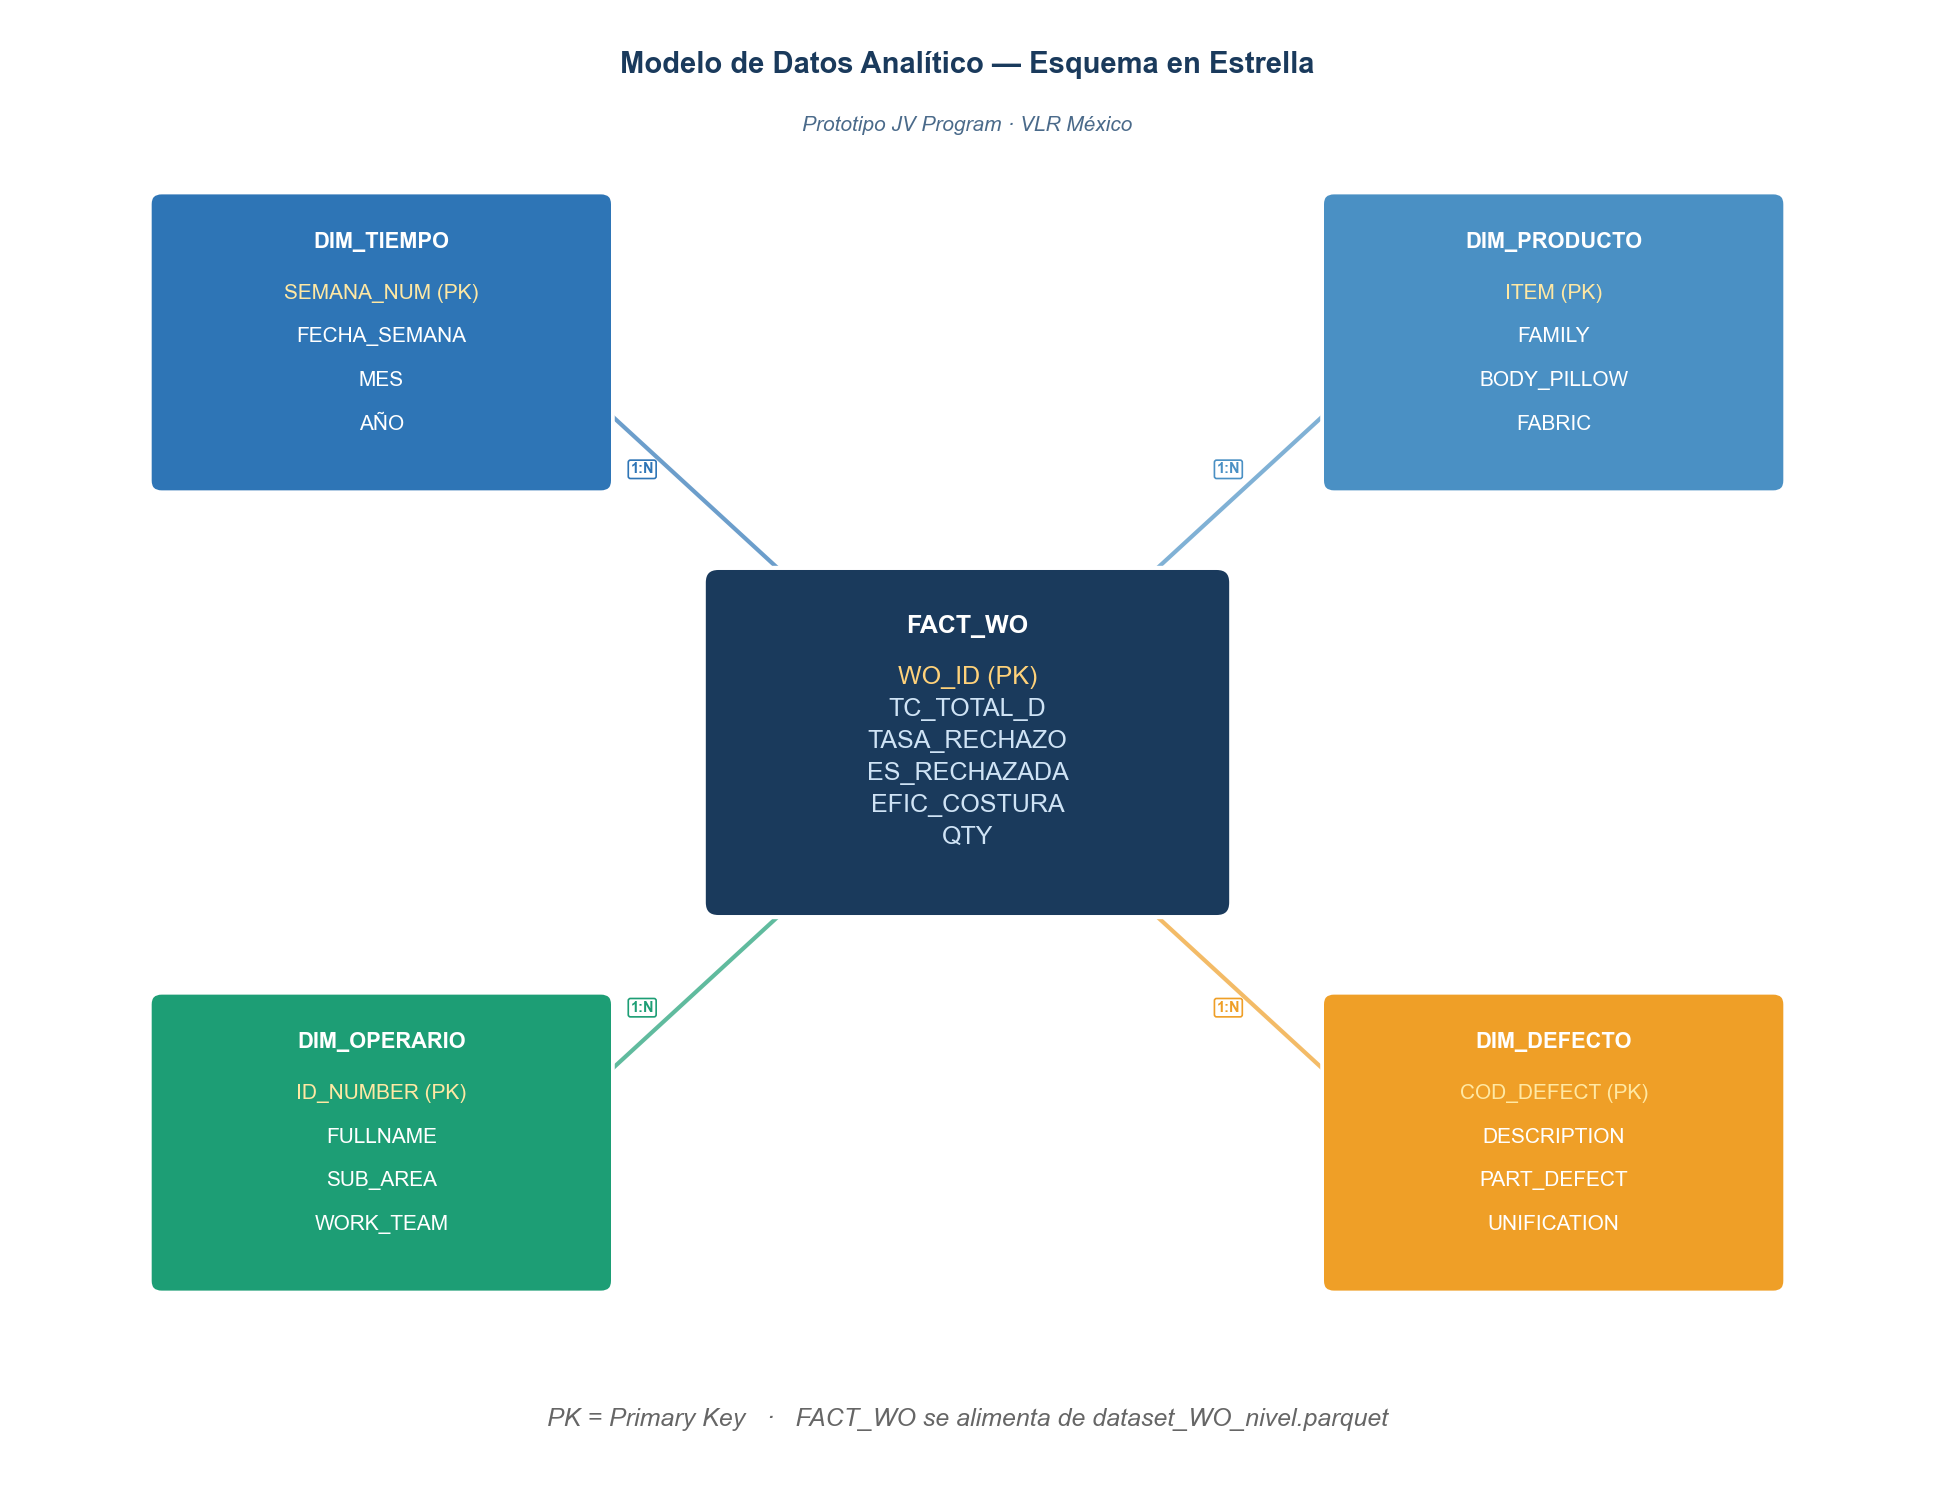

✅ figura30_modelo_datos_estrella.png  (141.3 KB)


In [5]:
 
# ══════════════════════════════════════════════════════════════════════════════
#  FIGURA 30 — Modelo de datos analítico (esquema en estrella)
# ══════════════════════════════════════════════════════════════════════════════
# ── CELDA 4 ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 10))
ax.set_xlim(0, 13)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_facecolor("white")
 
ax.text(6.5, 9.6, "Modelo de Datos Analítico — Esquema en Estrella",
        ha="center", fontsize=14, fontweight="bold", color=COLOR_DARK)
ax.text(6.5, 9.2, "Prototipo JV Program · VLR México",
        ha="center", fontsize=10, color="#4a6a8a", style="italic")
 
# ── Tabla de hechos central ──────────────────────────────────────────────────
fact = FancyBboxPatch((4.8, 3.9), 3.4, 2.2, boxstyle="round,pad=0.1",
                       facecolor=COLOR_DARK, edgecolor="white", linewidth=2, zorder=4)
ax.add_patch(fact)
ax.text(6.5, 5.75, "FACT_WO", ha="center", fontsize=12,
        fontweight="bold", color="white", zorder=5)
campos_fact = ["WO_ID (PK)", "TC_TOTAL_D", "TASA_RECHAZO",
               "ES_RECHAZADA", "EFIC_COSTURA", "QTY"]
for i, c in enumerate(campos_fact):
    ax.text(6.5, 5.4 - i*0.22, c, ha="center", fontsize=12,
            color="#CFE3F5" if "PK" not in c else "#FFD27A", zorder=5)
 
# ── Dimensiones (4 alrededor) ────────────────────────────────────────────────
dims = [
    (1.0, 6.8, "DIM_TIEMPO", COLOR_CORP,
     ["SEMANA_NUM (PK)", "FECHA_SEMANA", "MES", "AÑO"]),
    (9.0, 6.8, "DIM_PRODUCTO", "#4A90C4",
     ["ITEM (PK)", "FAMILY", "BODY_PILLOW", "FABRIC"]),
    (1.0, 1.3, "DIM_OPERARIO", COLOR_TEAL,
     ["ID_NUMBER (PK)", "FULLNAME", "SUB_AREA", "WORK_TEAM"]),
    (9.0, 1.3, "DIM_DEFECTO", COLOR_AMBER,
     ["COD_DEFECT (PK)", "DESCRIPTION", "PART_DEFECT", "UNIFICATION"]),
]
 
for x, y, label, color, campos in dims:
    box = FancyBboxPatch((x, y), 3.0, 1.9, boxstyle="round,pad=0.08",
                          facecolor=color, edgecolor="white", linewidth=1.8, zorder=3)
    ax.add_patch(box)
    ax.text(x + 1.5, y + 1.6, label, ha="center", fontsize=10.5,
            fontweight="bold", color="white", zorder=4)
    for i, c in enumerate(campos):
        ax.text(x + 1.5, y + 1.25 - i*0.3, c, ha="center", fontsize=10,
                color="white" if "PK" not in c else "#FFE8A3", zorder=4)
 
    # Línea de conexión hacia la tabla de hechos
    cx, cy = x + 1.5, y + (0 if y < 5 else 1.9)
    fx, fy = 6.5, 5.0
    ax.plot([cx, fx], [cy, fy], color=color, lw=2, alpha=0.7, zorder=2,
            linestyle="-")
    # Marca "1" y "N" de cardinalidad
    ax.text((cx+fx)/2 - 0.3, (cy+fy)/2, "1:N", fontsize=7,
            color=color, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white",
                      edgecolor=color, linewidth=0.8))
 
# ── Leyenda ──────────────────────────────────────────────────────────────────
leg_y = 0.3
ax.text(6.5, leg_y, "PK = Primary Key   ·   FACT_WO se alimenta de dataset_WO_nivel.parquet",
        ha="center", fontsize=12, color="#666666", style="italic")
 
plt.tight_layout()
save("figura30_modelo_datos_estrella.png")

In [6]:
 
# ── CELDA 5: Resumen final ────────────────────────────────────────────────────
print("\n" + "="*55)
print("📁 FIGURAS DEL CAPÍTULO 8 GENERADAS")
print("="*55)
for f in sorted(os.listdir("figuras_cap8")):
    size = os.path.getsize(f"figuras_cap8/{f}") / 1024
    print(f"  {f:<45} {size:>6.1f} KB")
 
print("\nCorrespondencia con el documento Word:")
print("  figura28_arquitectura_prototipo.png        → Figura 28 (§ 8.1)")
print("  figura29_dashboard_mockup_prediccion.png    → Figura 29 (§ 8.2.3)")
print("  figura30_modelo_datos_estrella.png          → Figura 30 (§ 8.3)")
print("\n✅ Listas para insertar en los recuadros [IMAGEN] del documento")
 


📁 FIGURAS DEL CAPÍTULO 8 GENERADAS
  figura28_arquitectura_prototipo.png            185.3 KB
  figura29_dashboard_mockup_prediccion.png       157.6 KB
  figura30_modelo_datos_estrella.png             141.3 KB

Correspondencia con el documento Word:
  figura28_arquitectura_prototipo.png        → Figura 28 (§ 8.1)
  figura29_dashboard_mockup_prediccion.png    → Figura 29 (§ 8.2.3)
  figura30_modelo_datos_estrella.png          → Figura 30 (§ 8.3)

✅ Listas para insertar en los recuadros [IMAGEN] del documento
